# Indicator Screening & Backtesting Framework

This notebook demonstrates the full indicator framework:
1. **Individual indicators** — backtest a single indicator on one stock
2. **Composite indicators** — AND/OR multiple indicators together
3. **Universe screening** — find all stocks matching an indicator
4. **Multi-ticker backtesting** — trade a basket of screened stocks

In [1]:
import sys
sys.path.insert(0, '../..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from indicators import (
    composite_and, composite_or,
    create_sma_trend_indicator,
    create_ema_crossover_indicator,
    create_rsi_indicator,
    create_macd_crossover_indicator,
    create_volatility_spike_indicator,
    create_bollinger_squeeze_indicator,
    create_volume_spike_indicator,
    create_mean_reversion_indicator,
)
from strategies.indicator_strategy import create_indicator_strategy, create_screener_strategy
from utils.simulation import BacktestSimulation

## 1. Backtest Individual Indicators on AAPL

Test each indicator as a standalone buy/sell strategy on a single stock.

In [11]:
ticker = 'AAPL'
start = datetime(2016, 1, 1)
end = datetime(2026, 1, 1)
initial_cash = 10000

# Define indicators to test
indicators = {
    'SMA Trend (200d)': create_sma_trend_indicator(period=200),
    'EMA Crossover (12/26)': create_ema_crossover_indicator(short_period=12, long_period=26),
    'RSI Oversold (14d, <30)': create_rsi_indicator(period=14, signal='oversold'),
    'MACD Crossover': create_macd_crossover_indicator(),
    'Mean Reversion (200d, 10%)': create_mean_reversion_indicator(period=200, deviation_pct=0.10),
}

results = {}

for name, indicator in indicators.items():
    print(f"\n{'='*60}")
    print(f"Testing: {name}")
    print('='*60)
    
    strategy = create_indicator_strategy(ticker=ticker, indicator=indicator)
    
    sim = BacktestSimulation(
        tickers=[ticker],
        start_date=start,
        end_date=end,
        initial_cash=initial_cash,
        strategy_callback=strategy,
    )
    sim.run()
    sim.print_performance_stats()
    
    history = pd.DataFrame(sim.history)
    results[name] = history


Testing: SMA Trend (200d)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $48,468.46
Total Return: 384.68%
Sharpe Ratio: 0.80
Max Drawdown: 35.27%
Annualized Volatility: 23.03%

Testing: EMA Crossover (12/26)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $53,965.49
Total Return: 439.65%
Sharpe Ratio: 0.97
Max Drawdown: 27.46%
Annualized Volatility: 19.29%

Testing: RSI Oversold (14d, <30)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


...


=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $14,862.15
Total Return: 48.62%
Sharpe Ratio: 0.41
Max Drawdown: 12.89%
Annualized Volatility: 11.13%

Testing: MACD Crossover
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $82,280.67
Total Return: 722.81%
Sharpe Ratio: 1.28
Max Drawdown: 26.71%
Annualized Volatility: 17.70%

Testing: Mean Reversion (200d, 10%)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $14,355.24
Total Return: 43.55%
Sharpe Ratio: 0.39
Max Drawdown: 16.80%
Annualized Volatility: 10.66%


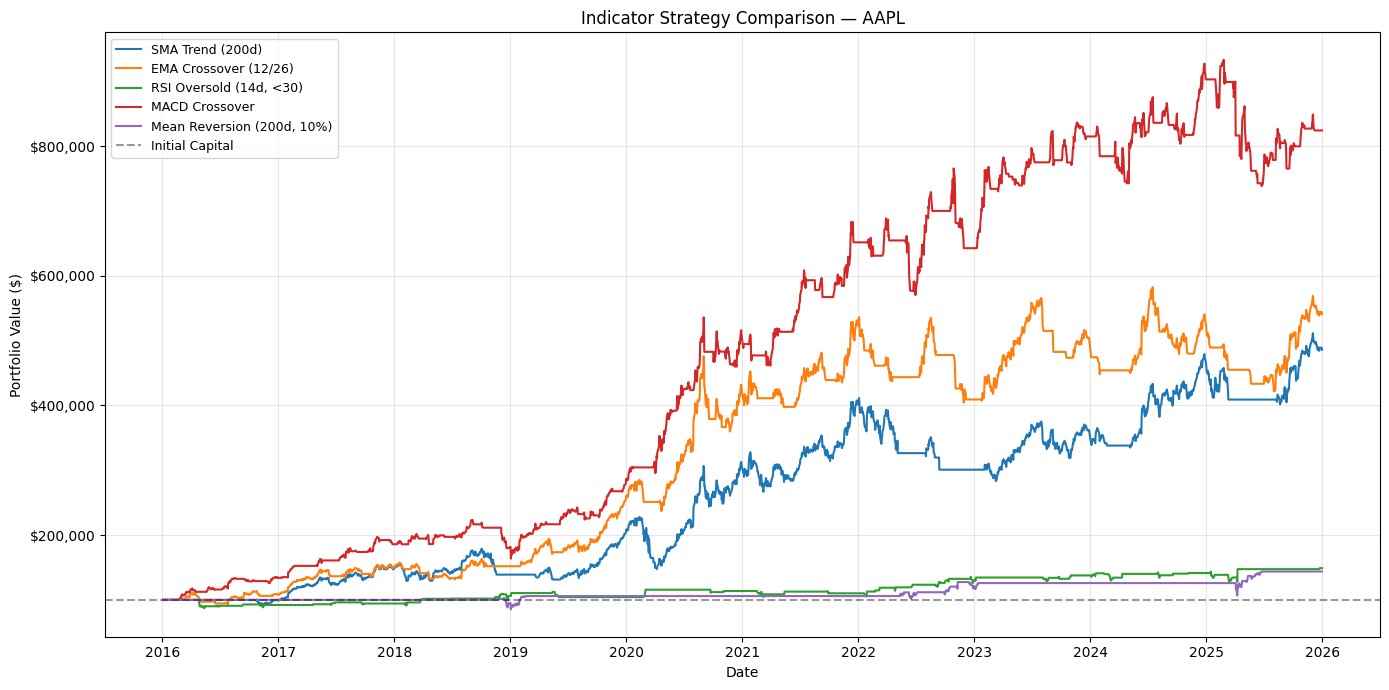

In [3]:
# Compare all indicators on a single chart
fig, ax = plt.subplots(figsize=(14, 7))

for name, history in results.items():
    ax.plot(history['date'], history['total_value'], label=name, linewidth=1.5)

ax.axhline(y=initial_cash, color='black', linestyle='--', alpha=0.4, label='Initial Capital')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value ($)')
ax.set_title(f'Indicator Strategy Comparison — {ticker}')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 2. Composite Indicators

Combine multiple indicators with AND logic — only buy when ALL indicators agree.

Composite indicator: SMA_Trend(200) AND EMA_Cross(12,26) AND MACD(12,26,9)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $10,000.00
Final Value: $31,735.01
Total Return: 217.35%
Sharpe Ratio: 0.97
Max Drawdown: 14.39%
Annualized Volatility: 12.82%


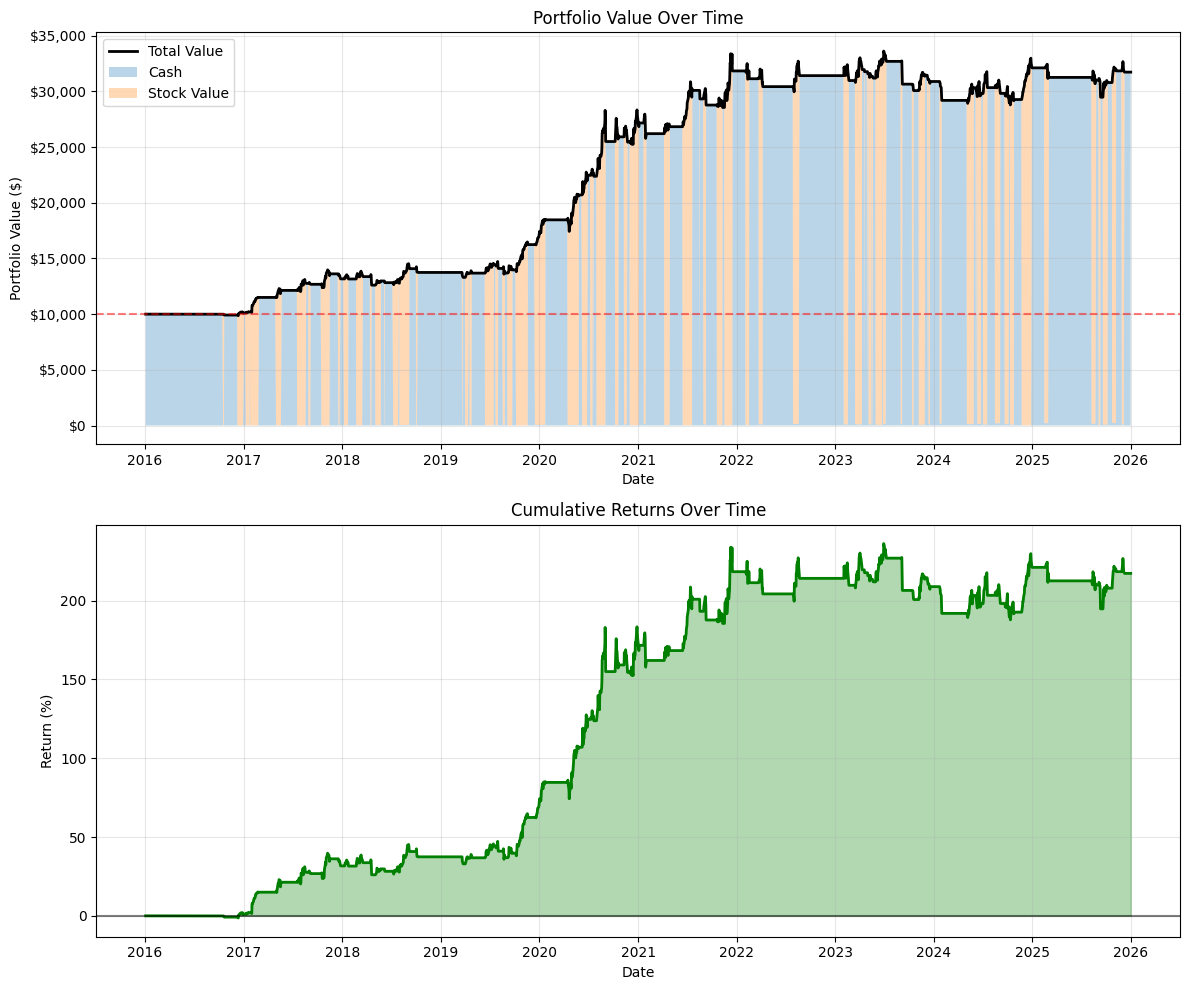

In [12]:
# Composite: uptrend + momentum confirmation
composite_bullish = composite_and(
    create_sma_trend_indicator(period=200),       # Price above 200-day SMA
    create_ema_crossover_indicator(12, 26),        # Short EMA > Long EMA
    create_macd_crossover_indicator(),              # MACD bullish
)

print(f"Composite indicator: {composite_bullish.__name__}")

strategy = create_indicator_strategy(ticker=ticker, indicator=composite_bullish)

sim = BacktestSimulation(
    tickers=[ticker],
    start_date=start,
    end_date=end,
    initial_cash=initial_cash,
    strategy_callback=strategy,
)
sim.run()
sim.print_performance_stats()
sim.plot_portfolio_history()

Composite indicator: MeanReversion(200,10%) AND RSI(14,oversold<30) AND VolumeSpike(20d,>1.5x)
Loading market data...
Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)



=== Performance Summary ===
Initial Value: $100,000.00
Final Value: $106,971.71
Total Return: 6.97%
Sharpe Ratio: 0.15
Max Drawdown: 7.24%
Annualized Volatility: 5.48%


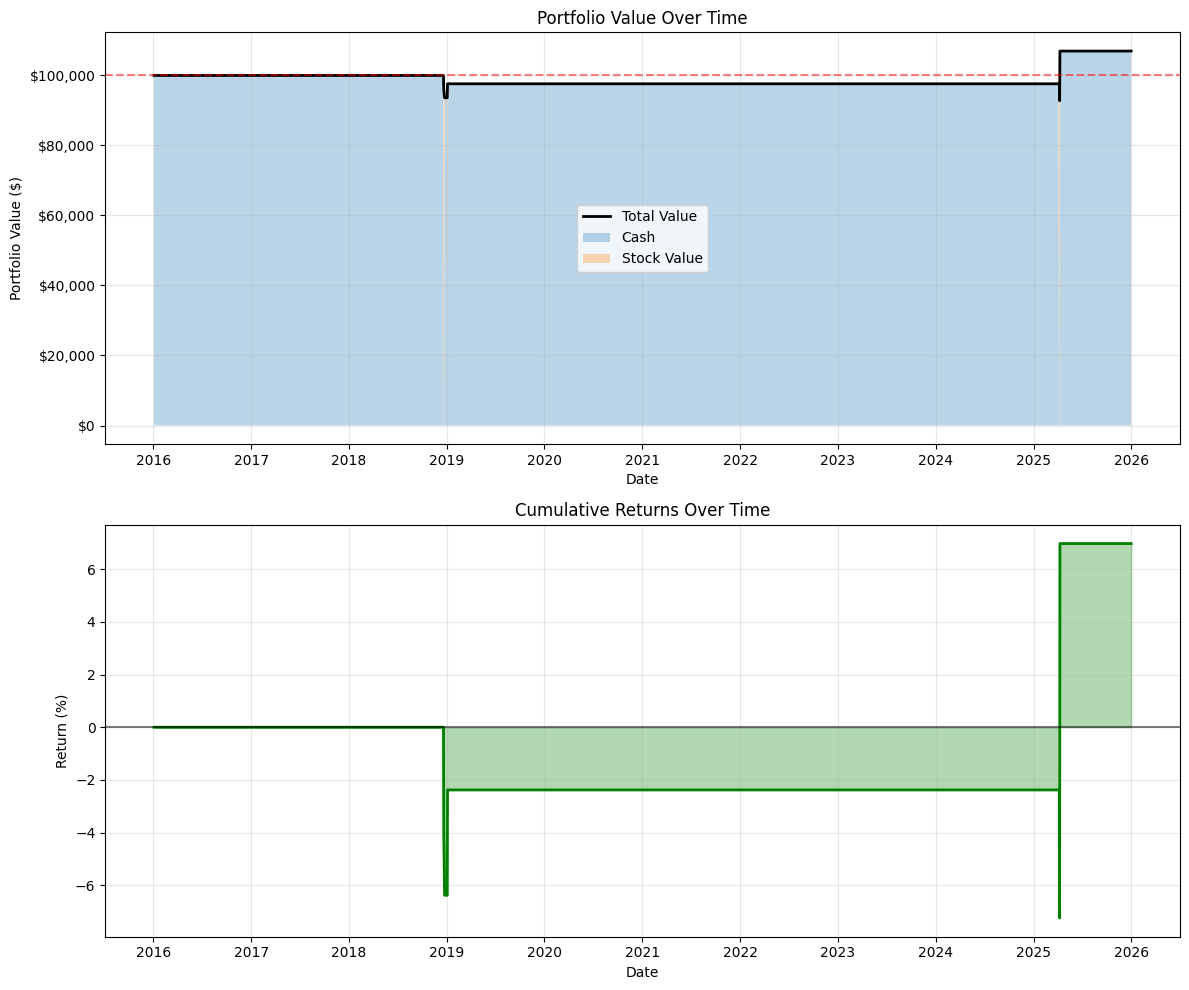

In [5]:
# Composite: mean reversion + oversold (contrarian buy signal)
composite_dip_buy = composite_and(
    create_mean_reversion_indicator(period=200, deviation_pct=0.10),
    create_rsi_indicator(period=14, signal='oversold'),
    create_volume_spike_indicator(lookback=20, spike_factor=1.5),
)

print(f"Composite indicator: {composite_dip_buy.__name__}")

strategy = create_indicator_strategy(ticker=ticker, indicator=composite_dip_buy)

sim = BacktestSimulation(
    tickers=[ticker],
    start_date=start,
    end_date=end,
    initial_cash=initial_cash,
    strategy_callback=strategy,
)
sim.run()
sim.print_performance_stats()
sim.plot_portfolio_history()

## 3. Universe Screening

Run indicators across a set of tickers to find matches. Here we use the Mag 7 as a small demo universe.

In [6]:
from screener import StockScreener

screener = StockScreener()

# Demo with Mag 7
demo_universe = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'TSLA']

# Which Mag 7 stocks are currently in an uptrend?
trend_indicator = create_sma_trend_indicator(period=200)
uptrend_tickers = screener.screen(
    indicator=trend_indicator,
    tickers=demo_universe,
    min_history_days=200,
)
print(f"\nMag 7 stocks above 200-day SMA: {uptrend_tickers}")

Loading data for 7 tickers in 1 batches (100/batch, 4 workers)...


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../screener/data_loader.py:103: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, end=end, progress=False, threads=True)


  Progress: 1/1 batches, 7 tickers loaded
Loaded 7 tickers successfully
[SMA_Trend(200)] Screened 7 tickers, 0 matches, 0 errors

Mag 7 stocks above 200-day SMA: []


In [7]:
# Detailed screen: show which indicators fire for each ticker
detail_indicators = {
    'Above 200d SMA': create_sma_trend_indicator(200),
    'EMA Bullish': create_ema_crossover_indicator(12, 26),
    'RSI Oversold': create_rsi_indicator(14, signal='oversold'),
    'MACD Bullish': create_macd_crossover_indicator(),
    'Vol Spike': create_volatility_spike_indicator(60, 1.5),
    'Volume Spike': create_volume_spike_indicator(20, 2.0),
}

detail_df = screener.screen_detail(
    indicators=detail_indicators,
    tickers=demo_universe,
    min_history_days=200,
)
print("\nDetailed Indicator Screen:")
display(detail_df)

Loading data for 7 tickers in 1 batches (100/batch, 4 workers)...
  Progress: 1/1 batches, 7 tickers loaded
Loaded 7 tickers successfully
Screened 7 tickers, 3 had at least one indicator fire

Detailed Indicator Screen:


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../screener/data_loader.py:103: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=start, end=end, progress=False, threads=True)


,Above 200d SMA,EMA Bullish,RSI Oversold,MACD Bullish,Vol Spike,Volume Spike
ticker,,,,,,
AMZN,False,False,False,True,False,False
META,False,False,True,False,False,False
MSFT,False,False,True,False,False,False


## 4. Multi-Ticker Screener Backtest

Use `create_screener_strategy` to backtest trading on indicator signals across multiple tickers simultaneously.

Loading market data...


/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end=self.end_date, progress=False)
/Users/ryan/git/quantitative-trading-models/strategies/screening/../../utils/simulation.py:36: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=self.start_date, end

Running simulation from 2016-01-04 to 2025-12-31
Total trading days: 2514

=== Performance Summary ===
Initial Value: $100,000.00
Final Value: $287,092.64
Total Return: 187.09%
Sharpe Ratio: 1.22
Max Drawdown: 10.63%
Annualized Volatility: 8.99%


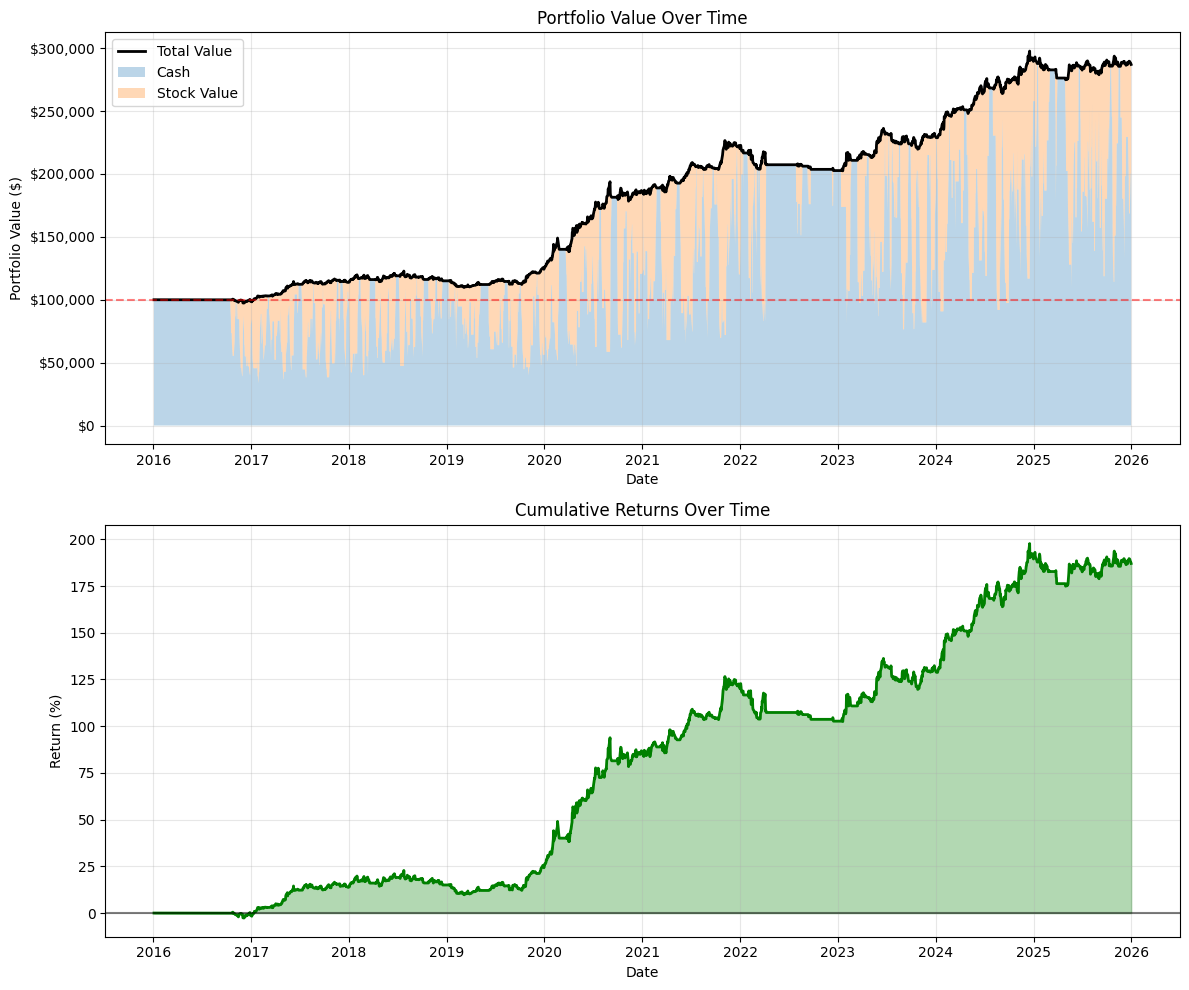

In [8]:
# Backtest: buy any Mag 7 stock where SMA trend + MACD are both bullish
multi_indicator = composite_and(
    create_sma_trend_indicator(200),
    create_macd_crossover_indicator(),
)

screener_strategy = create_screener_strategy(
    indicator=multi_indicator,
    max_positions=7,
)

sim = BacktestSimulation(
    tickers=demo_universe,
    start_date=start,
    end_date=end,
    initial_cash=initial_cash,
    strategy_callback=screener_strategy,
)
sim.run()
sim.print_performance_stats()
sim.plot_portfolio_history()

In [9]:
# Transaction summary
tx = sim.get_transactions()
if not tx.empty:
    print(f"Total transactions: {len(tx)}")
    print(f"\nBy action:")
    print(tx['action'].value_counts())
    print(f"\nBy ticker:")
    print(tx['ticker'].value_counts())
else:
    print("No transactions recorded")

Total transactions: 1203

By action:
action
BUY_STOCK     603
SELL_STOCK    600
Name: count, dtype: int64

By ticker:
ticker
MSFT     193
GOOGL    188
AMZN     185
META     170
NVDA     161
TSLA     158
AAPL     148
Name: count, dtype: int64


## 5. Full Universe Screening (Optional)

Uncomment to screen the entire US stock universe. This downloads data for thousands of tickers and may take several minutes.

In [10]:
# from screener import get_us_stock_universe
# 
# universe = get_us_stock_universe()
# print(f"Total US stocks: {len(universe)}")
# 
# full_screener = StockScreener()
# 
# # Find all stocks that are oversold with a volume spike
# dip_signal = composite_and(
#     create_mean_reversion_indicator(period=200, deviation_pct=0.15),
#     create_rsi_indicator(period=14, signal='oversold'),
# )
# 
# matches = full_screener.screen(
#     indicator=dip_signal,
#     tickers=universe,
#     min_history_days=200,
# )
# print(f"\nStocks matching dip-buy criteria: {matches}")